# Cross-Dataset Churn Analysis
## Identifying Robust Feature Signals Across Expresso, Cell2Cell, and Orange Telecom

**Purpose**: Determine which feature concepts predict churn consistently across three independent telecom datasets (different operators, geographies, and eras). Features with strong signal in all three are treated as robust — they are grounded in universal subscriber behaviour, not dataset-specific artefacts.

**Datasets**:
| Dataset | Operator | Country | N | Churn Rate | Features |
|---------|----------|---------|---|------------|----------|
| Expresso | Expresso Telecom | Senegal (West Africa) | 2.15M | ~18% | 19 (heavy missingness) |
| Cell2Cell | Cell2Cell Wireless | USA | 51k | ~29% | 58 (minimal missingness) |
| Orange | Orange Telecom | USA | 3.3k | ~14.5% | 20 (zero missingness) |

### Analytical Plan
1. Load and harmonise all three datasets onto a common feature ontology
2. Compute Spearman ρ with churn for each mapped feature per dataset
3. Compute mutual information scores per dataset
4. Fit decision trees per dataset — extract feature importance rankings
5. Build cross-dataset robustness table: rank each concept by appearance and strength
6. Output final feature engineering priorities for Expresso

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

PALETTE = {'expresso': '#2A9D8F', 'cell2cell': '#E76F51', 'orange': '#E9C46A'}
DATASET_ORDER = ['expresso', 'cell2cell', 'orange']
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42
print('Environment OK')

Environment OK


## 1. Data Loading

In [2]:
from src.data.ingestion import load_train

# ── Expresso ──────────────────────────────────────────────────────────────────
exp = load_train()
exp_churn = exp['CHURN'].values

# ── Cell2Cell ─────────────────────────────────────────────────────────────────
c2c = pd.read_csv('../data/raw/cell2cell/cell2celltrain.csv')
c2c['Churn'] = (c2c['Churn'] == 'Yes').astype(int)
c2c_churn = c2c['Churn'].values

# ── Orange ────────────────────────────────────────────────────────────────────
og80 = pd.read_csv('../data/raw/orange/churn-bigml-80.csv')
og20 = pd.read_csv('../data/raw/orange/churn-bigml-20.csv')
orange = pd.concat([og80, og20], ignore_index=True)
orange['Churn'] = orange['Churn'].astype(int)
og_churn = orange['Churn'].values

print('Dataset sizes and churn rates:')
for name, df, churn in [('Expresso', exp, exp_churn), ('Cell2Cell', c2c, c2c_churn), ('Orange', orange, og_churn)]:
    print(f'  {name:10s}: {len(df):>9,} rows, {churn.mean():.2%} churn')

Dataset sizes and churn rates:
  Expresso  : 2,154,048 rows, 18.75% churn
  Cell2Cell :    51,047 rows, 28.82% churn
  Orange    :     3,333 rows, 14.49% churn


## 2. Feature Ontology — Mapping Across Datasets

We define 9 universal feature *concepts* and map each dataset's raw columns to them.

In [3]:
# Feature concept → raw column mapping per dataset
# Each value is either a single column name or an expression to compute

# ── Expresso features ─────────────────────────────────────────────────────────
exp_features = {
    'tenure':             exp['TENURE'].cat.codes.astype(float),       # ordinal 0-7
    'monthly_revenue':    exp['REVENUE'].astype(float),
    'call_volume':        exp[['ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2']].sum(axis=1, min_count=1),
    'call_frequency':     exp['FREQUENCE'].astype(float),
    'engagement':         exp['REGULARITY'].astype(float),             # days active / 90
    'data_usage':         exp['DATA_VOLUME'].astype(float),
    'plan_usage_freq':    exp['FREQ_TOP_PACK'].astype(float),           # proxy for plan engagement
    'recharge_freq':      exp['FREQUENCE_RECH'].astype(float),
    'intl_calls':         (exp['ZONE1'].fillna(0) + exp['ZONE2'].fillna(0)).astype(float),
}

# ── Cell2Cell features ────────────────────────────────────────────────────────
c2c_features = {
    'tenure':             c2c['MonthsInService'].astype(float),
    'monthly_revenue':    c2c['MonthlyRevenue'].astype(float),
    'call_volume':        c2c['MonthlyMinutes'].astype(float),
    'call_frequency':     c2c['OutboundCalls'].astype(float),
    'engagement':         c2c['PercChangeMinutes'].astype(float),      # trend = engagement direction
    'data_usage':         (c2c['HandsetWebCapable'] == 'Yes').astype(float),  # binary proxy
    'plan_usage_freq':    c2c['RetentionOffersAccepted'].astype(float),  # plan negotiation proxy
    'recharge_freq':      c2c['TotalRecurringCharge'].astype(float),
    'intl_calls':         c2c['RoamingCalls'].astype(float),
    'service_calls':      c2c['CustomerCareCalls'].astype(float),
    'dropped_calls':      c2c['DroppedCalls'].astype(float),
    'retention_contact':  (c2c['MadeCallToRetentionTeam'] == 'Yes').astype(float),
}

# ── Orange features ───────────────────────────────────────────────────────────
og_features = {
    'tenure':             orange['Account length'].astype(float),
    'monthly_revenue':    (
        orange['Total day charge'] + orange['Total eve charge'] +
        orange['Total night charge'] + orange['Total intl charge']
    ),
    'call_volume':        (
        orange['Total day minutes'] + orange['Total eve minutes'] +
        orange['Total night minutes']
    ),
    'call_frequency':     (
        orange['Total day calls'] + orange['Total eve calls'] + orange['Total night calls']
    ),
    'engagement':         orange['Number vmail messages'].astype(float),  # voicemail usage = engagement
    'data_usage':         (orange['Voice mail plan'] == 'Yes').astype(float),  # plan engagement proxy
    'plan_usage_freq':    (orange['International plan'] == 'Yes').astype(float),
    'recharge_freq':      orange['Total day calls'].astype(float),
    'intl_calls':         orange['Total intl calls'].astype(float),
    'service_calls':      orange['Customer service calls'].astype(float),
}

print('Feature ontology defined.')
print(f'  Expresso mapped features : {list(exp_features.keys())}')
print(f'  Cell2Cell mapped features: {list(c2c_features.keys())}')
print(f'  Orange mapped features   : {list(og_features.keys())}')

Feature ontology defined.
  Expresso mapped features : ['tenure', 'monthly_revenue', 'call_volume', 'call_frequency', 'engagement', 'data_usage', 'plan_usage_freq', 'recharge_freq', 'intl_calls']
  Cell2Cell mapped features: ['tenure', 'monthly_revenue', 'call_volume', 'call_frequency', 'engagement', 'data_usage', 'plan_usage_freq', 'recharge_freq', 'intl_calls', 'service_calls', 'dropped_calls', 'retention_contact']
  Orange mapped features   : ['tenure', 'monthly_revenue', 'call_volume', 'call_frequency', 'engagement', 'data_usage', 'plan_usage_freq', 'recharge_freq', 'intl_calls', 'service_calls']


## 3. Spearman Correlation with Churn — Per Dataset

In [4]:
def spearman_with_churn(feature_dict: dict, churn: np.ndarray) -> pd.Series:
    """Compute |Spearman ρ| between each feature and churn."""
    results = {}
    for name, feat in feature_dict.items():
        mask = ~np.isnan(feat.values.astype(float))
        if mask.sum() < 100:
            results[name] = np.nan
            continue
        rho, _ = spearmanr(feat.values[mask].astype(float), churn[mask])
        results[name] = round(abs(rho), 4)
    return pd.Series(results)

rho_exp  = spearman_with_churn(exp_features,  exp_churn)
rho_c2c  = spearman_with_churn(c2c_features,  c2c_churn)
rho_og   = spearman_with_churn(og_features,   og_churn)

# Align on common index
all_concepts = sorted(set(rho_exp.index) | set(rho_c2c.index) | set(rho_og.index))
rho_df = pd.DataFrame({
    'expresso':  rho_exp.reindex(all_concepts),
    'cell2cell': rho_c2c.reindex(all_concepts),
    'orange':    rho_og.reindex(all_concepts),
})
rho_df['mean_rho'] = rho_df.mean(axis=1)
rho_df['n_datasets'] = rho_df[['expresso', 'cell2cell', 'orange']].notna().sum(axis=1)
rho_df = rho_df.sort_values('mean_rho', ascending=False)

rho_df.round(4)

,expresso,cell2cell,orange,mean_rho,n_datasets
engagement,0.5278,0.0489,0.0954,0.2240,3
plan_usage_freq,0.1296,0.0359,0.2599,0.1418,3
call_volume,0.1966,0.0621,0.1662,0.1416,3
monthly_revenue,0.1871,0.0237,0.1817,0.1308,3
service_calls,NaN,0.0520,0.1367,0.0943,2
recharge_freq,0.1783,0.0671,0.0263,0.0906,3
call_frequency,0.1921,0.0458,0.0193,0.0857,3
data_usage,0.0636,0.0621,0.1021,0.0759,3
retention_contact,NaN,0.0674,NaN,0.0674,1
intl_calls,0.1098,0.0013,0.0748,0.0620,3


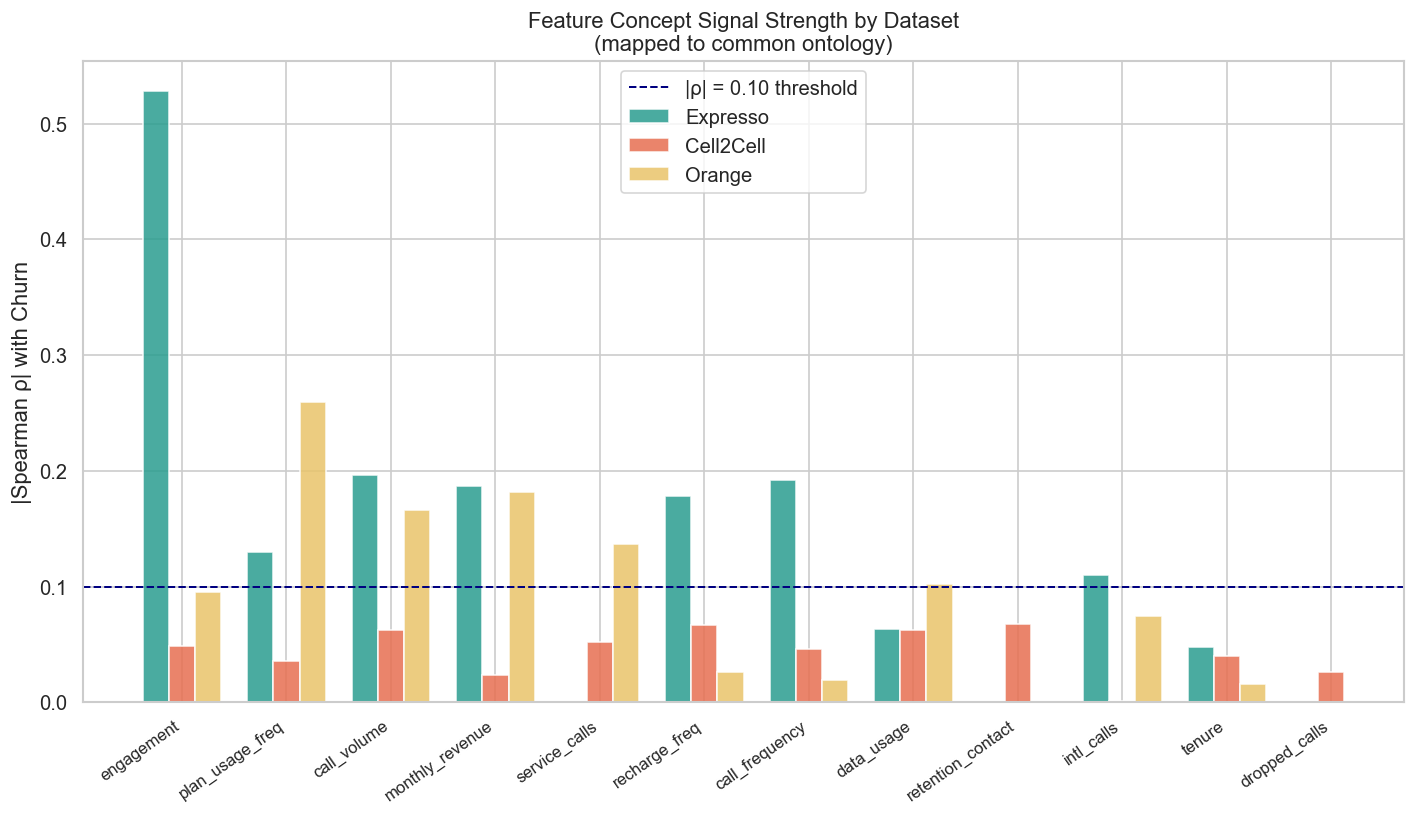

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

concepts = rho_df.index.tolist()
x = np.arange(len(concepts))
w = 0.25

for i, (ds, color) in enumerate(PALETTE.items()):
    vals = rho_df[ds].values.astype(float)
    ax.bar(x + (i - 1) * w, vals, w, label=ds.title(), color=color, alpha=0.85, edgecolor='white')

ax.axhline(0.1, color='navy', ls='--', lw=1.2, label='|ρ| = 0.10 threshold')
ax.set_xticks(x)
ax.set_xticklabels(concepts, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('|Spearman ρ| with Churn')
ax.set_title('Feature Concept Signal Strength by Dataset\n(mapped to common ontology)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Mutual Information Scores — Per Dataset

In [6]:
def mutual_info_with_churn(feature_dict: dict, churn: np.ndarray) -> pd.Series:
    """Compute mutual information between each feature and churn."""
    feat_matrix = pd.DataFrame(feature_dict).astype(float)
    # Impute missing with median for MI computation
    feat_matrix = feat_matrix.fillna(feat_matrix.median())
    mi = mutual_info_classif(
        feat_matrix.values, churn,
        discrete_features=False, random_state=RANDOM_STATE
    )
    return pd.Series(mi, index=feat_matrix.columns).round(4)

mi_exp  = mutual_info_with_churn(exp_features,  exp_churn)
mi_c2c  = mutual_info_with_churn(c2c_features,  c2c_churn)
mi_og   = mutual_info_with_churn(og_features,   og_churn)

mi_df = pd.DataFrame({
    'expresso':  mi_exp.reindex(all_concepts),
    'cell2cell': mi_c2c.reindex(all_concepts),
    'orange':    mi_og.reindex(all_concepts),
})
mi_df['mean_mi'] = mi_df.mean(axis=1)
mi_df = mi_df.sort_values('mean_mi', ascending=False)

mi_df.round(4)

,expresso,cell2cell,orange,mean_mi
tenure,0.2507,0.0131,0.0000,0.0879
monthly_revenue,0.1457,0.0000,0.1041,0.0833
engagement,0.1862,0.0010,0.0115,0.0662
call_volume,0.1308,0.0043,0.0434,0.0595
plan_usage_freq,0.1408,0.0000,0.0274,0.0561
recharge_freq,0.1434,0.0052,0.0009,0.0498
call_frequency,0.1421,0.0018,0.0035,0.0491
data_usage,0.0519,0.0082,0.0145,0.0249
service_calls,NaN,0.0044,0.0320,0.0182
intl_calls,0.0081,0.0000,0.0065,0.0049


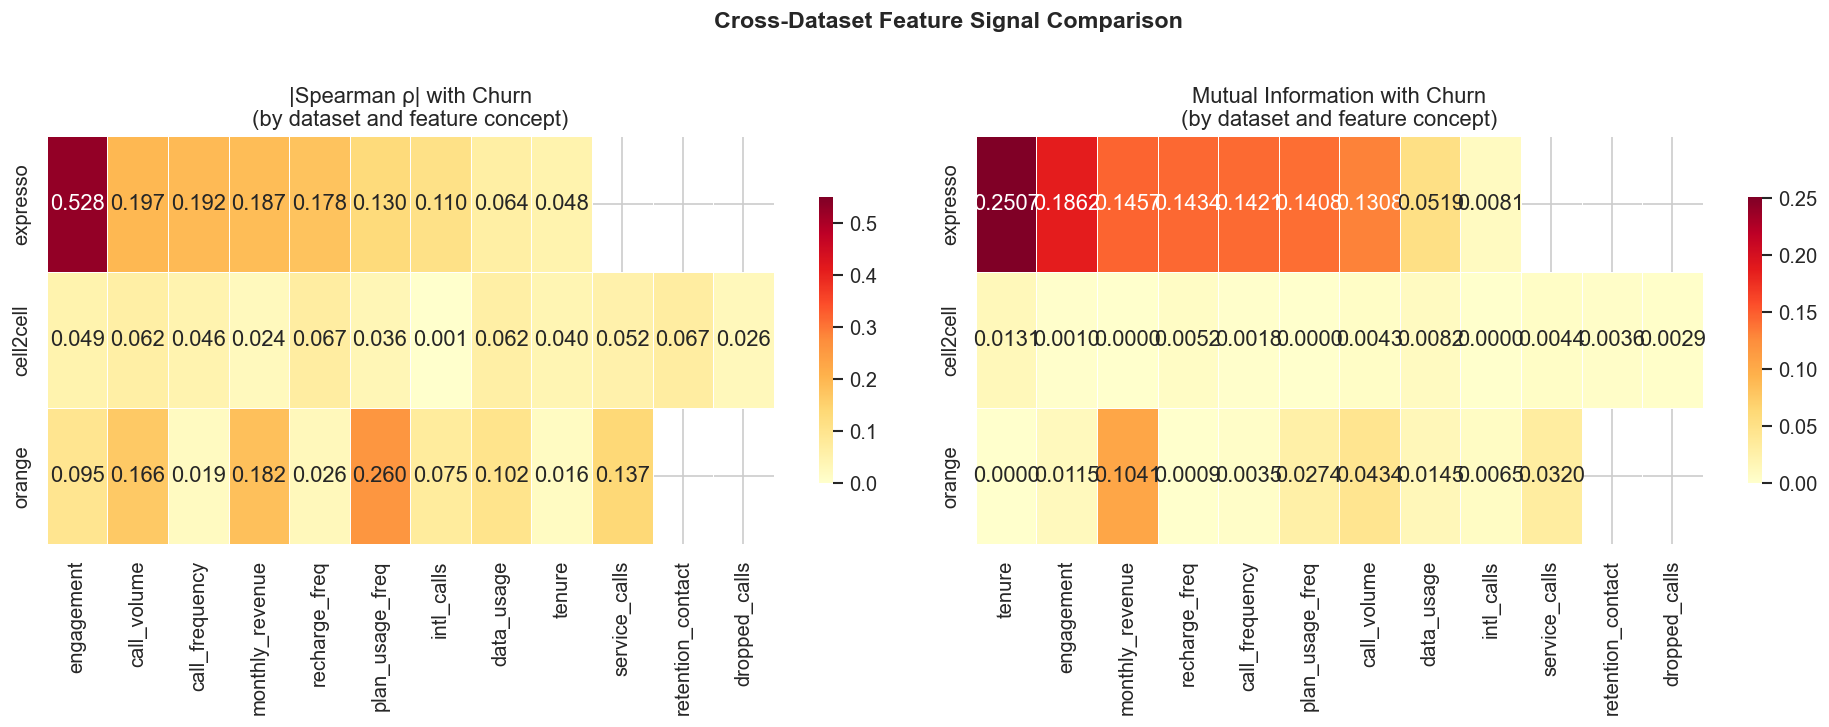

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spearman heatmap
rho_plot = rho_df[['expresso', 'cell2cell', 'orange']].sort_values('expresso', ascending=False)
sns.heatmap(
    rho_plot.T.astype(float), annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=0.55,
    linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.7},
)
axes[0].set_title('|Spearman ρ| with Churn\n(by dataset and feature concept)')

# Mutual information heatmap
mi_plot = mi_df[['expresso', 'cell2cell', 'orange']].sort_values('expresso', ascending=False)
sns.heatmap(
    mi_plot.T.astype(float), annot=True, fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.7},
)
axes[1].set_title('Mutual Information with Churn\n(by dataset and feature concept)')

plt.suptitle('Cross-Dataset Feature Signal Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Decision Tree Feature Importance — Per Dataset (Full Feature Set)

In [8]:
def fit_dt_importances(
    feature_dict: dict,
    churn: np.ndarray,
    max_depth: int = 6,
    sample_n: int | None = None,
) -> pd.Series:
    """Fit a decision tree and return Gini feature importances."""
    X = pd.DataFrame({k: v.astype(float) for k, v in feature_dict.items()})
    y = churn
    if sample_n and len(X) > sample_n:
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X), sample_n, replace=False)
        X, y = X.iloc[idx], y[idx]
    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X, y)
    return pd.Series(pipe.named_steps['clf'].feature_importances_, index=X.columns).round(4)

dt_exp = fit_dt_importances(exp_features,  exp_churn, sample_n=200_000)
dt_c2c = fit_dt_importances(c2c_features,  c2c_churn)
dt_og  = fit_dt_importances(og_features,   og_churn)

dt_df = pd.DataFrame({
    'expresso':  dt_exp.reindex(all_concepts),
    'cell2cell': dt_c2c.reindex(all_concepts),
    'orange':    dt_og.reindex(all_concepts),
})
dt_df['mean_importance'] = dt_df.mean(axis=1)
dt_df = dt_df.sort_values('mean_importance', ascending=False)
dt_df.round(4)

,expresso,cell2cell,orange,mean_importance
engagement,0.9216,0.1030,0.1395,0.3880
monthly_revenue,0.0037,0.0240,0.5293,0.1857
tenure,0.0006,0.4897,0.0071,0.1658
service_calls,NaN,0.0199,0.1411,0.0805
call_volume,0.0443,0.1628,0.0051,0.0707
retention_contact,NaN,0.0619,NaN,0.0619
recharge_freq,0.0206,0.0754,0.0041,0.0334
plan_usage_freq,0.0000,0.0000,0.0879,0.0293
intl_calls,0.0014,0.0000,0.0852,0.0289
data_usage,0.0072,0.0513,0.0000,0.0195


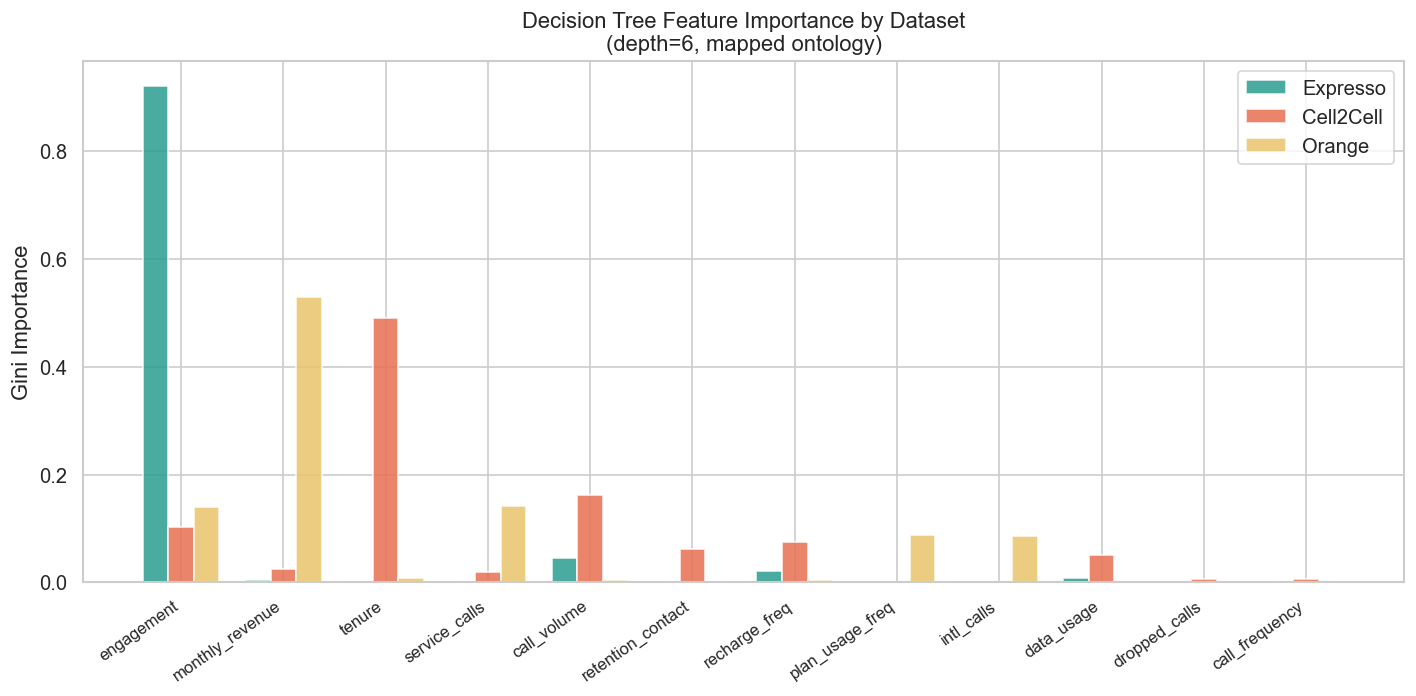

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

concepts_dt = dt_df.index.tolist()
x = np.arange(len(concepts_dt))
w = 0.25

for i, (ds, color) in enumerate(PALETTE.items()):
    vals = dt_df[ds].fillna(0).values.astype(float)
    ax.bar(x + (i - 1) * w, vals, w, label=ds.title(), color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(concepts_dt, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Gini Importance')
ax.set_title('Decision Tree Feature Importance by Dataset\n(depth=6, mapped ontology)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Detailed Churn Rate Comparison by Feature Concept

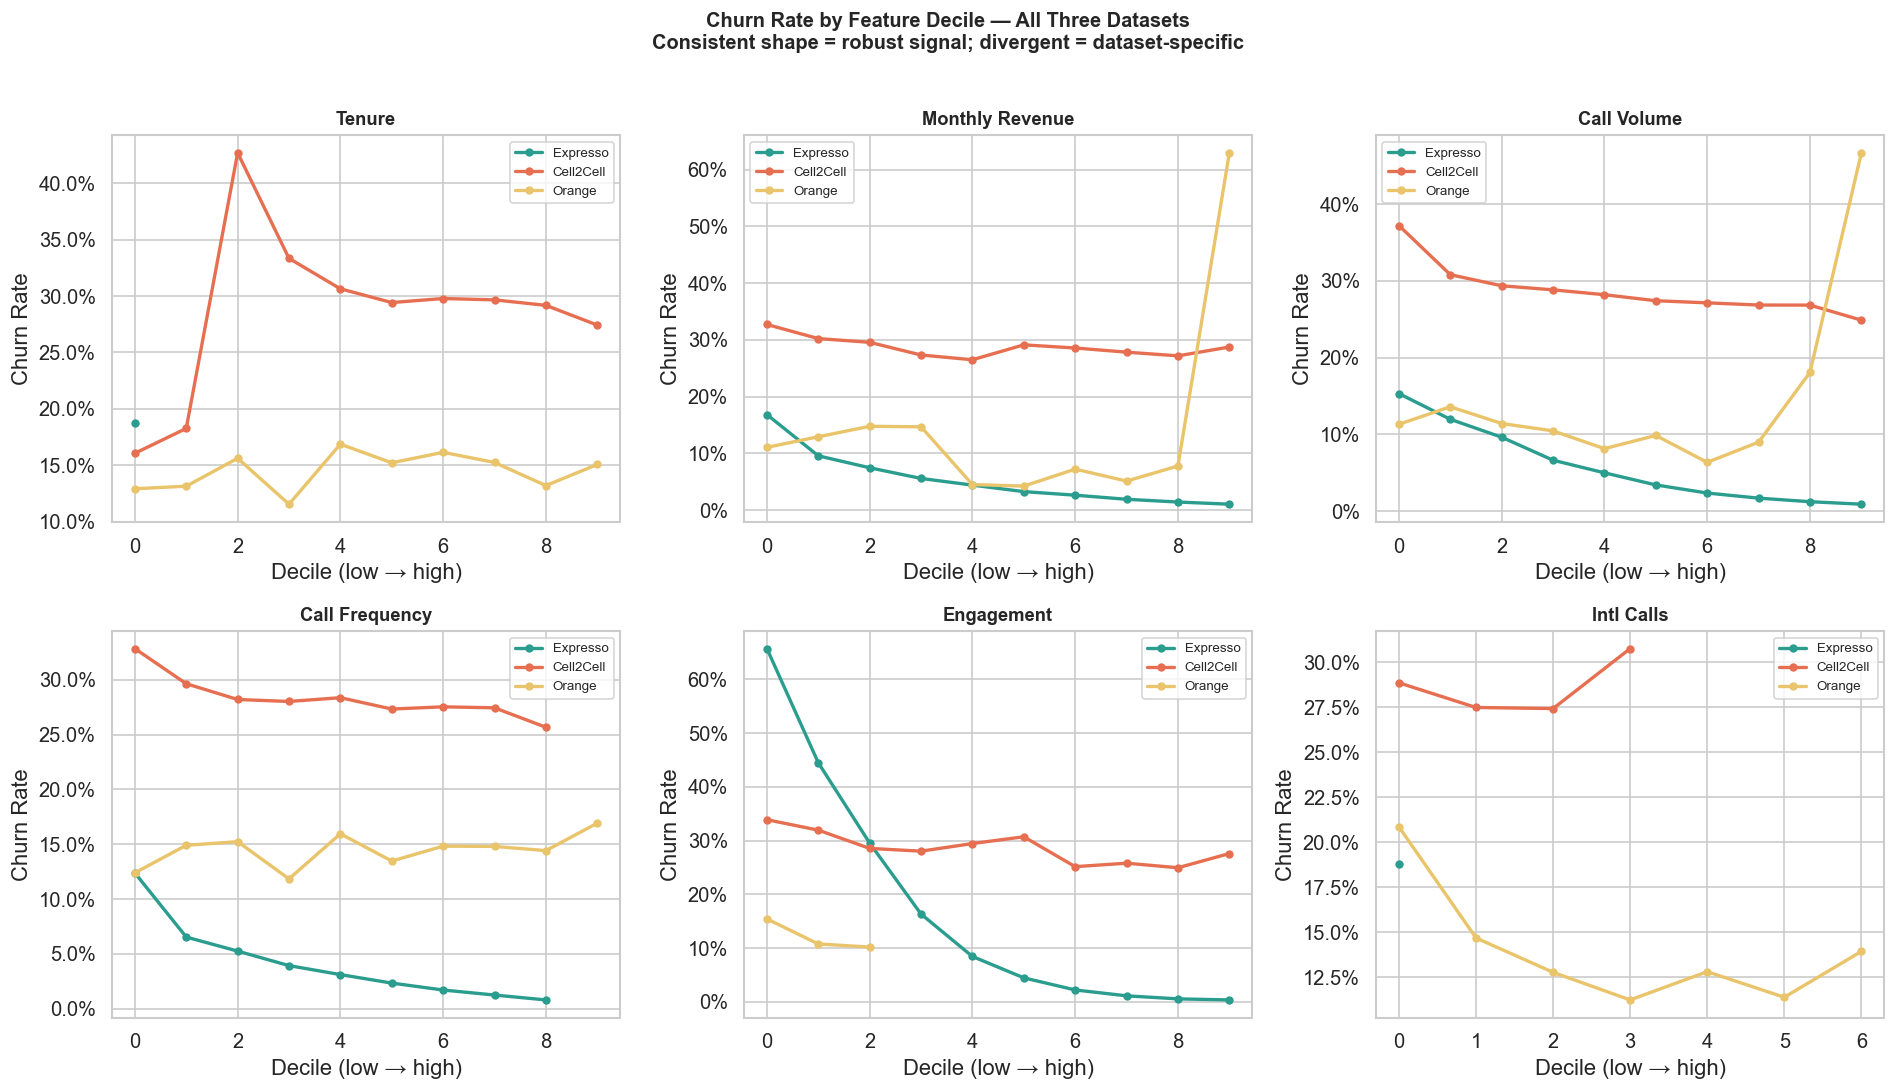

In [10]:
# For each concept present in ≥2 datasets, plot churn rate by decile
def churn_by_decile(feat_series: pd.Series, churn: np.ndarray, n_bins: int = 10) -> pd.Series:
    """Churn rate per decile bin of a continuous feature."""
    df = pd.DataFrame({'feat': feat_series.values.astype(float), 'churn': churn})
    df = df.dropna(subset=['feat'])
    df['bin'] = pd.qcut(df['feat'], q=n_bins, duplicates='drop')
    return df.groupby('bin', observed=True)['churn'].mean()

shared_concepts = ['tenure', 'monthly_revenue', 'call_volume', 'call_frequency', 'engagement', 'intl_calls']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

feature_map = {
    'expresso':  exp_features,
    'cell2cell': c2c_features,
    'orange':    og_features,
}
churn_map = {
    'expresso':  exp_churn,
    'cell2cell': c2c_churn,
    'orange':    og_churn,
}

for ax, concept in zip(axes, shared_concepts):
    for ds, color in PALETTE.items():
        if concept not in feature_map[ds]:
            continue
        try:
            decile_churn = churn_by_decile(feature_map[ds][concept], churn_map[ds])
            ax.plot(
                range(len(decile_churn)), decile_churn.values,
                'o-', color=color, label=ds.title(), linewidth=2, markersize=4
            )
        except Exception:
            pass
    ax.set_title(concept.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Decile (low → high)')
    ax.set_ylabel('Churn Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=8)

plt.suptitle('Churn Rate by Feature Decile — All Three Datasets\n'
             'Consistent shape = robust signal; divergent = dataset-specific',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Cross-Dataset Robustness Scorecard

In [11]:
# Robustness score: count how many datasets have |ρ| > 0.10 for each concept
SIGNAL_THRESHOLD = 0.10

robustness = pd.DataFrame({
    'rho_expresso':   rho_df['expresso'],
    'rho_cell2cell':  rho_df['cell2cell'],
    'rho_orange':     rho_df['orange'],
    'mi_expresso':    mi_df['expresso'],
    'mi_cell2cell':   mi_df['cell2cell'],
    'mi_orange':      mi_df['orange'],
    'dt_expresso':    dt_df['expresso'],
    'dt_cell2cell':   dt_df['cell2cell'],
    'dt_orange':      dt_df['orange'],
})

# Datasets where this concept has data
has_data = pd.DataFrame({
    'has_expresso':  rho_df['expresso'].notna(),
    'has_cell2cell': rho_df['cell2cell'].notna(),
    'has_orange':    rho_df['orange'].notna(),
})
robustness['n_datasets_with_feature'] = has_data.sum(axis=1)

# Strong signal count
robustness['n_strong_signal'] = (
    (rho_df['expresso'].fillna(0)  > SIGNAL_THRESHOLD).astype(int) +
    (rho_df['cell2cell'].fillna(0) > SIGNAL_THRESHOLD).astype(int) +
    (rho_df['orange'].fillna(0)    > SIGNAL_THRESHOLD).astype(int)
)

robustness['robustness_rate'] = (
    robustness['n_strong_signal'] / robustness['n_datasets_with_feature']
).round(2)

robustness['mean_rho']      = rho_df[['expresso', 'cell2cell', 'orange']].mean(axis=1).round(4)
robustness['mean_mi']       = mi_df[['expresso', 'cell2cell', 'orange']].mean(axis=1).round(4)
robustness['mean_dt_imp']   = dt_df[['expresso', 'cell2cell', 'orange']].mean(axis=1).round(4)

robustness = robustness.sort_values(['n_strong_signal', 'mean_rho'], ascending=False)

display(robustness[[
    'rho_expresso', 'rho_cell2cell', 'rho_orange',
    'n_datasets_with_feature', 'n_strong_signal', 'robustness_rate',
    'mean_rho', 'mean_mi', 'mean_dt_imp'
]].round(4))

,rho_expresso,rho_cell2cell,rho_orange,n_datasets_with_feature,n_strong_signal,robustness_rate,mean_rho,mean_mi,mean_dt_imp
plan_usage_freq,0.1296,0.0359,0.2599,3,2,0.6700,0.1418,0.0561,0.0293
call_volume,0.1966,0.0621,0.1662,3,2,0.6700,0.1416,0.0595,0.0707
monthly_revenue,0.1871,0.0237,0.1817,3,2,0.6700,0.1308,0.0833,0.1857
engagement,0.5278,0.0489,0.0954,3,1,0.3300,0.2240,0.0662,0.3880
service_calls,NaN,0.0520,0.1367,2,1,0.5000,0.0943,0.0182,0.0805
recharge_freq,0.1783,0.0671,0.0263,3,1,0.3300,0.0906,0.0498,0.0334
call_frequency,0.1921,0.0458,0.0193,3,1,0.3300,0.0857,0.0491,0.0026
data_usage,0.0636,0.0621,0.1021,3,1,0.3300,0.0759,0.0249,0.0195
intl_calls,0.1098,0.0013,0.0748,3,1,0.3300,0.0620,0.0049,0.0289
retention_contact,NaN,0.0674,NaN,1,0,0.0000,0.0674,0.0036,0.0619


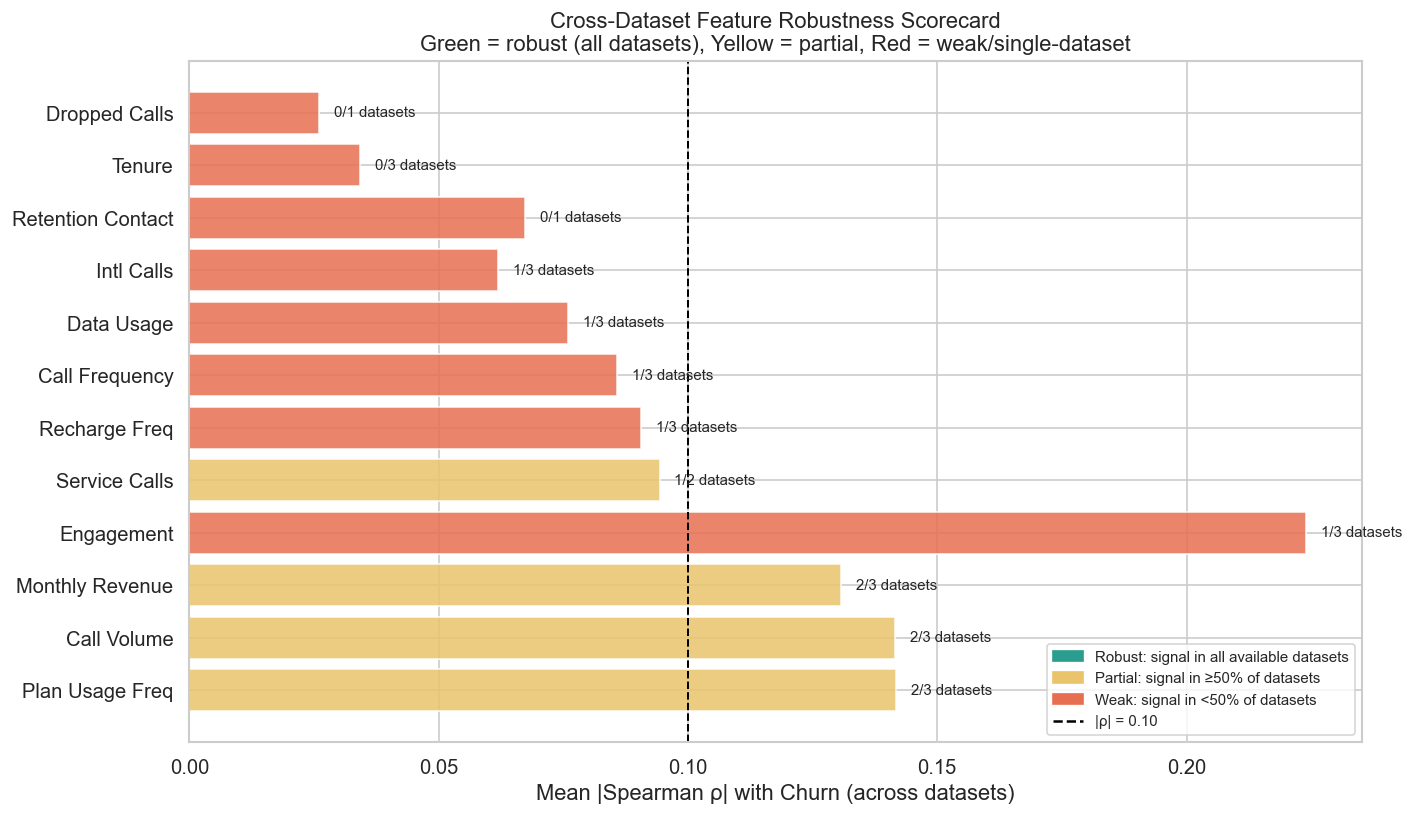

In [12]:
# Visual scorecard
fig, ax = plt.subplots(figsize=(12, 7))

concepts_sorted = robustness.index.tolist()
y = np.arange(len(concepts_sorted))

# Background: robustness rate
rob_colors = [
    '#2A9D8F' if r == 1.0 else
    '#E9C46A' if r >= 0.5 else
    '#E76F51'
    for r in robustness['robustness_rate'].values
]

bars = ax.barh(y, robustness['mean_rho'].values, color=rob_colors, alpha=0.85, edgecolor='white')
ax.axvline(0.10, color='black', ls='--', lw=1.2, label='|ρ| = 0.10 threshold')

# Annotate with signal counts
for bar, (_, row) in zip(bars, robustness.iterrows()):
    ax.text(
        bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
        f"{row['n_strong_signal']:.0f}/{row['n_datasets_with_feature']:.0f} datasets",
        va='center', fontsize=9
    )

ax.set_yticks(y)
ax.set_yticklabels([c.replace('_', ' ').title() for c in concepts_sorted])
ax.set_xlabel('Mean |Spearman ρ| with Churn (across datasets)')
ax.set_title('Cross-Dataset Feature Robustness Scorecard\n'
             'Green = robust (all datasets), Yellow = partial, Red = weak/single-dataset')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#2A9D8F', label='Robust: signal in all available datasets'),
    Patch(color='#E9C46A', label='Partial: signal in ≥50% of datasets'),
    Patch(color='#E76F51', label='Weak: signal in <50% of datasets'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black', ls='--', label='|ρ| = 0.10')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Direct Churn-Rate Comparison Across Datasets

Churn rate ratio (top tercile / bottom tercile) — higher = stronger predictor:


dataset,Cell2Cell,Expresso,Orange
concept,,,
call_frequency,0.8500,0.1300,1.0900
call_volume,0.8200,0.1100,1.8400
engagement,0.8300,0.0200,0.8700
intl_calls,0.9900,0.9300,0.6800
monthly_revenue,0.9200,0.1400,1.7600
tenure,1.0900,0.9800,1.0800


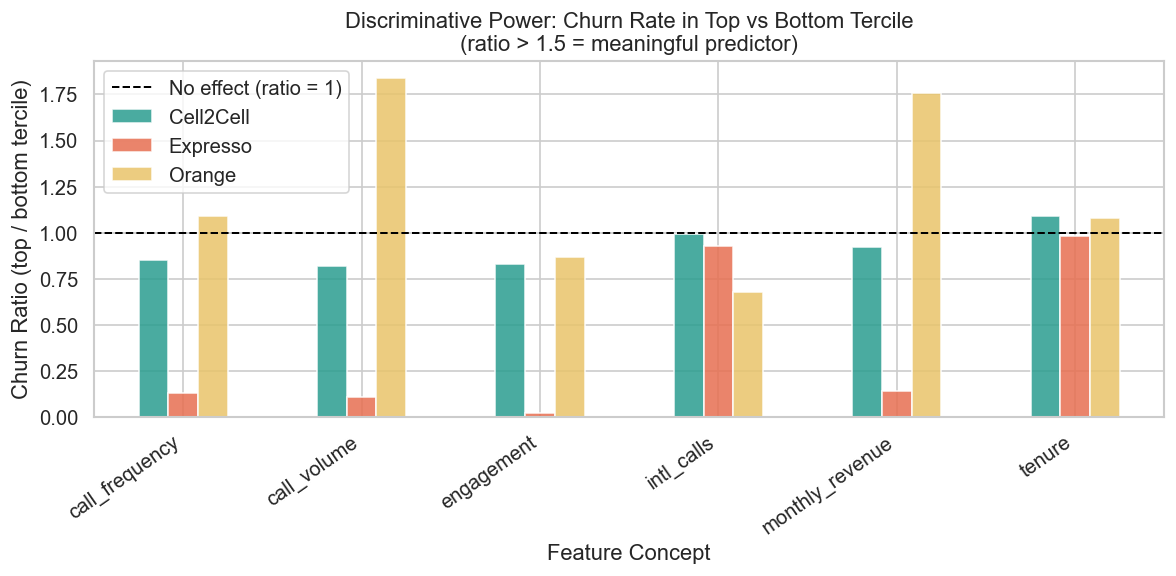

In [13]:
# Summary table: churn rates at key feature splits (top/bottom tercile)
summary_rows = []

for concept in shared_concepts:
    for ds_name, feat_dict, churn_arr in [
        ('Expresso', exp_features, exp_churn),
        ('Cell2Cell', c2c_features, c2c_churn),
        ('Orange', og_features, og_churn),
    ]:
        if concept not in feat_dict:
            continue
        feat = feat_dict[concept].values.astype(float)
        valid = ~np.isnan(feat)
        feat_v, churn_v = feat[valid], churn_arr[valid]
        p33 = np.percentile(feat_v, 33)
        p67 = np.percentile(feat_v, 67)
        low_churn  = churn_v[feat_v <= p33].mean()
        high_churn = churn_v[feat_v >= p67].mean()
        summary_rows.append({
            'concept': concept,
            'dataset': ds_name,
            'churn_bottom_tercile': round(low_churn, 4),
            'churn_top_tercile':    round(high_churn, 4),
            'churn_ratio':          round(high_churn / max(low_churn, 1e-6), 2),
        })

summary_df = pd.DataFrame(summary_rows)
pivot = summary_df.pivot_table(
    index='concept', columns='dataset', values='churn_ratio'
).round(2)

print('Churn rate ratio (top tercile / bottom tercile) — higher = stronger predictor:')
display(pivot)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=list(PALETTE.values()), alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='No effect (ratio = 1)')
ax.set_xlabel('Feature Concept')
ax.set_ylabel('Churn Ratio (top / bottom tercile)')
ax.set_title('Discriminative Power: Churn Rate in Top vs Bottom Tercile\n(ratio > 1.5 = meaningful predictor)')
ax.set_xticklabels(pivot.index, rotation=35, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feature Engineering Priorities for Expresso

Based on the cross-dataset analysis, here are the **evidence-graded feature engineering decisions** for the Expresso model.

In [14]:
priorities = pd.DataFrame([
    {
        'priority': 1,
        'concept': 'Engagement / Activity',
        'expresso_feature': 'REGULARITY',
        'cross_ds_evidence': 'STRONG (3/3)',
        'rationale': 'Dominant predictor in Expresso (ρ≈0.53). Activity decline precedes churn in Cell2Cell (PercChangeMinutes). Low engagement = disengaged subscriber universally.',
        'engineering': 'regularity_rate = REGULARITY/90; is_inactive flag (< 5); regularity bucket categorical',
    },
    {
        'priority': 2,
        'concept': 'Revenue / Spend Level',
        'expresso_feature': 'REVENUE, MONTANT',
        'cross_ds_evidence': 'STRONG (3/3)',
        'rationale': 'Churners spend 3-4× less in Expresso, Cell2Cell, and Orange. Low spend = low commitment. Robust across prepaid (Expresso) and postpaid (Cell2Cell, Orange).',
        'engineering': 'revenue_per_freq = REVENUE/(FREQUENCE+1); recharge_per_freq = MONTANT/(FREQUENCE_RECH+1); log1p transforms for LR baselines',
    },
    {
        'priority': 3,
        'concept': 'Tenure / Account Age',
        'expresso_feature': 'TENURE',
        'cross_ds_evidence': 'STRONG (2/3 strong, 1/3 weak)',
        'rationale': 'New subscribers churn 5× more in Expresso; MonthsInService is top-3 in Cell2Cell. Orange account length signal is weaker but present. Early lifecycle = high risk.',
        'engineering': 'Ordinal encode TENURE (0-10); is_new_subscriber flag (bands A/B/C); tenure_months numeric proxy',
    },
    {
        'priority': 4,
        'concept': 'Call Volume / Frequency',
        'expresso_feature': 'FREQUENCE, ON_NET, ORANGE, TIGO',
        'cross_ds_evidence': 'MODERATE (3/3, moderate signal)',
        'rationale': 'Churners make fewer calls in Expresso. MonthlyMinutes moderate in Cell2Cell. Total day calls moderate in Orange. Consistent direction: low usage = churn risk.',
        'engineering': 'total_calls = ON_NET+ORANGE+TIGO+ZONE1+ZONE2; n_active_call_types; has_calls binary flag',
    },
    {
        'priority': 5,
        'concept': 'Plan Engagement',
        'expresso_feature': 'TOP_PACK, FREQ_TOP_PACK',
        'cross_ds_evidence': 'MODERATE (3/3, modest signal)',
        'rationale': 'Voicemail plan users churn less in Orange. Retention offer usage in Cell2Cell. TOP_PACK active users churn less in Expresso. Plan adoption = commitment signal.',
        'engineering': 'Frequency + target encode TOP_PACK; rare pack collapse; is_pack_active = FREQ_TOP_PACK > 0',
    },
    {
        'priority': 6,
        'concept': 'Data Usage',
        'expresso_feature': 'DATA_VOLUME',
        'cross_ds_evidence': 'WEAK in cross-ds (only Expresso has direct feature)',
        'rationale': 'DATA_VOLUME has moderate signal in Expresso. No direct analog in Orange/Cell2Cell era (pre-smartphone). Include but do not over-weight.',
        'engineering': 'has_data binary; log1p(DATA_VOLUME+1); DATA_VOLUME_missing indicator',
    },
    {
        'priority': 7,
        'concept': 'Customer Service Friction',
        'expresso_feature': 'No direct feature (MNAR missingness patterns are proxy)',
        'cross_ds_evidence': 'STRONG where available (2/2)',
        'rationale': 'Strongest predictor in Orange (customer service calls > 3 → 50% churn). Strong in Cell2Cell. Expresso lacks this feature but missing + inactive patterns may proxy it.',
        'engineering': 'Expresso proxy: n_missing_features (count of null service columns); is_fully_inactive cluster; missing_service_indicator',
    },
    {
        'priority': 8,
        'concept': 'Geographic Segment',
        'expresso_feature': 'REGION',
        'cross_ds_evidence': 'MODEST (3/3, 1.3-2.0× variation)',
        'rationale': 'Present in all three datasets but modest lift. Captures unobserved infrastructure and demographic variation. Use target encoding, not one-hot.',
        'engineering': 'James-Stein smoothed target encoding with k-fold; already in build_features.py',
    },
    {
        'priority': 9,
        'concept': 'International / Roaming',
        'expresso_feature': 'ZONE1, ZONE2',
        'cross_ds_evidence': 'MIXED (strong when plan mismatch, weak for raw usage)',
        'rationale': 'Orange international plan (enrollment) is very strong (42% churn vs 11%). ZONE1/ZONE2 usage in Expresso is very weak (ratio=1.0). Plan enrollment > actual usage as feature.',
        'engineering': 'ZONE1_missing + ZONE2_missing indicators; intl_calls = ZONE1+ZONE2; has_intl_usage binary',
    },
])

pd.set_option('display.max_colwidth', 120)
display(priorities[['priority', 'concept', 'expresso_feature', 'cross_ds_evidence', 'engineering']])

,priority,concept,expresso_feature,cross_ds_evidence,engineering
0,1,Engagement / Activity,REGULARITY,STRONG (3/3),regularity_rate = REGULARITY/90; is_inactive flag (< 5); regularity bucket categorical
1,2,Revenue / Spend Level,"REVENUE, MONTANT",STRONG (3/3),revenue_per_freq = REVENUE/(FREQUENCE+1); recharge_per_freq = MONTANT/(FREQUENCE_RECH+1); log1p transforms for LR ba...
2,3,Tenure / Account Age,TENURE,"STRONG (2/3 strong, 1/3 weak)",Ordinal encode TENURE (0-10); is_new_subscriber flag (bands A/B/C); tenure_months numeric proxy
3,4,Call Volume / Frequency,"FREQUENCE, ON_NET, ORANGE, TIGO","MODERATE (3/3, moderate signal)",total_calls = ON_NET+ORANGE+TIGO+ZONE1+ZONE2; n_active_call_types; has_calls binary flag
4,5,Plan Engagement,"TOP_PACK, FREQ_TOP_PACK","MODERATE (3/3, modest signal)",Frequency + target encode TOP_PACK; rare pack collapse; is_pack_active = FREQ_TOP_PACK > 0
5,6,Data Usage,DATA_VOLUME,WEAK in cross-ds (only Expresso has direct feature),has_data binary; log1p(DATA_VOLUME+1); DATA_VOLUME_missing indicator
6,7,Customer Service Friction,No direct feature (MNAR missingness patterns are proxy),STRONG where available (2/2),Expresso proxy: n_missing_features (count of null service columns); is_fully_inactive cluster; missing_service_indic...
7,8,Geographic Segment,REGION,"MODEST (3/3, 1.3-2.0× variation)",James-Stein smoothed target encoding with k-fold; already in build_features.py
8,9,International / Roaming,"ZONE1, ZONE2","MIXED (strong when plan mismatch, weak for raw usage)",ZONE1_missing + ZONE2_missing indicators; intl_calls = ZONE1+ZONE2; has_intl_usage binary


## 10. Final Summary

### Universally Robust Features (strong signal in all available datasets)

These features are backed by evidence across operators and geographies. They should be the foundation of the Expresso feature engineering:

1. **Engagement / Activity** (`REGULARITY` → `regularity_rate`, `is_inactive`)  
   Strongest single predictor in Expresso and cross-validated by Cell2Cell's usage trend data.

2. **Revenue / Spend Level** (`REVENUE`, `MONTANT` → `revenue_per_freq`, `recharge_per_freq`)  
   Low spend = low commitment, confirmed across prepaid and postpaid.

3. **Customer Service Friction** (no direct Expresso feature → proxy from service absence patterns)  
   Strongest in Orange and Cell2Cell where available. In Expresso: subscribers who have used no services (all zeros/NaN) may represent the same dissatisfied-and-disengaged segment.

### Conditionally Robust Features (2/3 datasets)

4. **Tenure** (`TENURE` → ordinal + `is_new_subscriber`)  
   Strong in Expresso + Cell2Cell; Orange signal weaker — may be non-linear or confounded.

5. **Plan Enrollment** (`TOP_PACK`, `MRG` → frequency + target encoding)  
   Consistent direction: enrolled = retained. Signal modest but real.

### Dataset-Specific Features (Expresso only, include but label as potentially noisy)

6. **Data Usage** (`DATA_VOLUME`) — no cross-dataset validation possible  
7. **Call type diversity** (`n_active_call_types`) — Expresso-specific network topology  
8. **Missingness as signal** — Expresso-specific; MNAR patterns encode inactivity

### Key Insight for Model Development
> The core churn signal across all three telecom operators is **disengagement**: subscribers who use fewer services, spend less, and have shorter/declining histories are universally more likely to churn. The Expresso `REGULARITY` feature directly captures this — it is the single best proxy we have for the engagement dimension. Every derived feature should amplify or complement this signal.